IMPORTS ET CONFIGURATION

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration des axes cibles
AXES_CIBLES = ["Bd_Richard_Lenoir", "Quai_Conti", "Sts_Peres"]
FICHIER_CSV = 'data/raw/comptages.csv'

print("🔧 Configuration chargée")
print(f"📂 Fichier cible : {FICHIER_CSV}")
print(f"🎯 Axes analysés : {AXES_CIBLES}")

🔧 Configuration chargée
📂 Fichier cible : data/raw/comptages.csv
🎯 Axes analysés : ['Bd_Richard_Lenoir', 'Quai_Conti', 'Sts_Peres']


Chargement par Chunks

In [5]:
print("⏳ Chargement des données par chunks...")
chunks = []

for chunk in pd.read_csv(FICHIER_CSV, sep=';', chunksize=100_000):
    chunk_filtre = chunk[chunk['libelle'].isin(AXES_CIBLES)]
    chunks.append(chunk_filtre)

df = pd.concat(chunks, ignore_index=True)
print(f"✅ Chargement terminé !")
print(f"📊 Nombre total de lignes : {len(df)}")
print(f"📐 Nombre de colonnes : {df.shape[1]}")

⏳ Chargement des données par chunks...
✅ Chargement terminé !
📊 Nombre total de lignes : 69824
📐 Nombre de colonnes : 11


Aperçu des données avec .head()

In [6]:
print("--- 📋 APERÇU DES DONNÉES (.head()) ---")
display(df.head())

--- 📋 APERÇU DES DONNÉES (.head()) ---


,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,1314,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,180.0,0.90333,Fluide,722,Bd_Richard_Lenoir-St_Sebastien,721,Bd_Richard_Lenoir-Pelee-Moufle,Ouvert
1,1317,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,83.0,0.25056,Fluide,721,Bd_Richard_Lenoir-Pelee-Moufle,722,Bd_Richard_Lenoir-St_Sebastien,Ouvert
2,1319,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,83.0,0.26889,Fluide,722,Bd_Richard_Lenoir-St_Sebastien,723,Bd_Richard_Lenoir-Chemin_Vert,Ouvert
3,69,Quai_Conti,2026-08-31T23:00:00+00:00,607.0,4.23000,Fluide,61,Pt_Neuf_Gauche,62,Quai_Conti-Guenegaud,Ouvert
4,70,Quai_Conti,2026-08-31T23:00:00+00:00,607.0,4.23000,Fluide,62,Quai_Conti-Guenegaud,63,Institut,Ouvert




Nous utilisons `.head()` pour visualiser les 5 premières lignes du jeu de données filtré. Cela nous permet de vérifier :
- La structure des colonnes
- Le format des données (timestamps, valeurs numériques)
- La présence effective de nos 3 axes cibles

Informations détaillé avec .info()

In [7]:
print("--- ℹ️ INFORMATIONS DÉTAILLÉES (.info()) ---")
df.info()

--- ℹ️ INFORMATIONS DÉTAILLÉES (.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 69824 entries, 0 to 69823
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   iu_ac             69824 non-null  int64  
 1   libelle           69824 non-null  str    
 2   t_1h              69824 non-null  str    
 3   q                 67576 non-null  float64
 4   k                 67827 non-null  float64
 5   etat_trafic       69824 non-null  str    
 6   iu_nd_amont       69824 non-null  int64  
 7   libelle_nd_amont  69824 non-null  str    
 8   iu_nd_aval        69824 non-null  int64  
 9   libelle_nd_aval   69824 non-null  str    
 10  etat_barre        69824 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 5.9 MB


Graphe 1: Distribution du debit

C:\Users\njjun\AppData\Local\Temp\ipykernel_11668\3474984443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='libelle', y='q', palette="Blues_d")


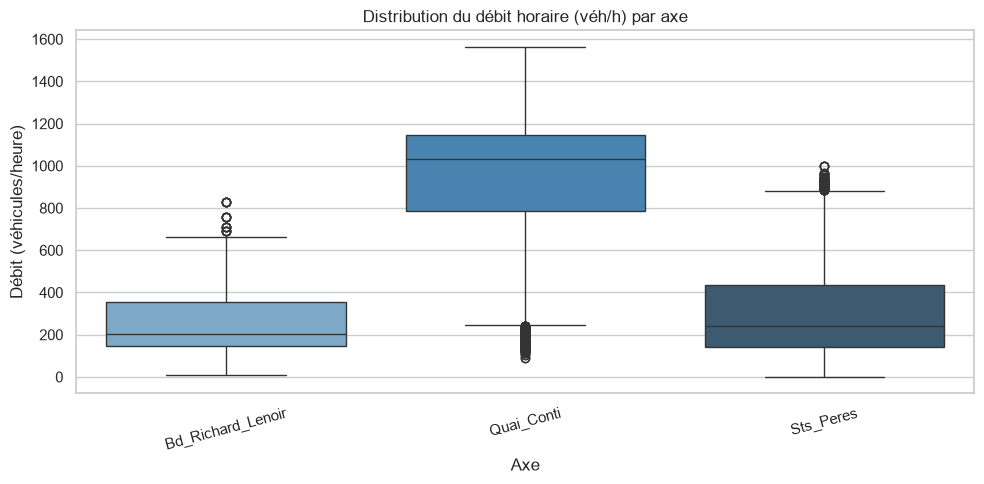

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='libelle', y='q', palette="Blues_d")
plt.title("Distribution du débit horaire (véh/h) par axe")
plt.xlabel("Axe")
plt.ylabel("Débit (véhicules/heure)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('graph1_debit.png', dpi=300)
plt.show()



Ce boxplot montre la répartition du débit horaire (en véhicules/heure) pour chaque axe. On observe que le Bd Richard Lenoir présente des débits beaucoup plus élevés, confirmant son rôle d'axe structurant puisque il est celui avec le plus de tronçons dont 10 par rapport aux autres 02 et 04.

Graphe 2 : Taux d'occupation

C:\Users\njjun\AppData\Local\Temp\ipykernel_11668\159451597.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='libelle', y='k_pct', palette="Reds_d")


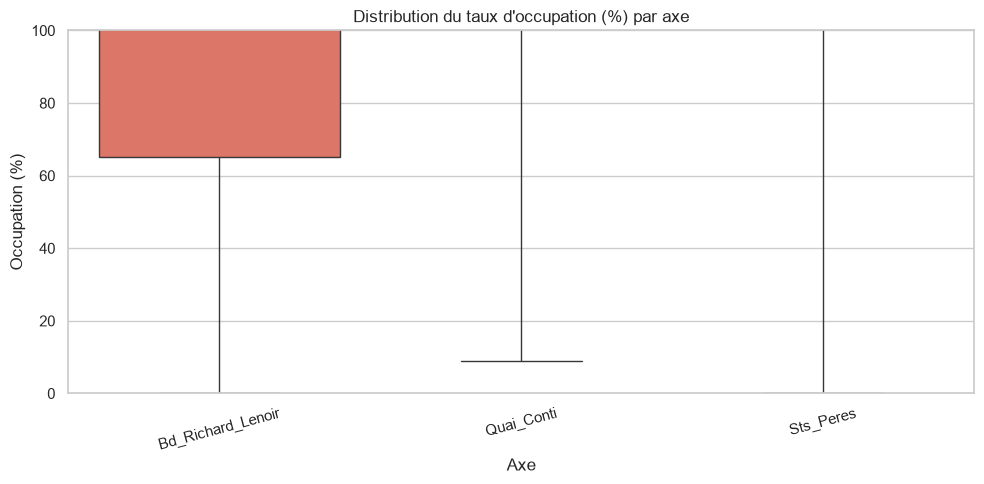

In [9]:
# Créer une colonne en pourcentage pour plus de lisibilité
df['k_pct'] = df['k'] * 100

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='libelle', y='k_pct', palette="Reds_d")
plt.title("Distribution du taux d'occupation (%) par axe")
plt.xlabel("Axe")
plt.ylabel("Occupation (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('graph2_occupation.png', dpi=300)
plt.show()


Le graphique révèle que le Quai Conti et la rue des Saints-Pères présentent des taux d'occupation proches de 100 % de manière quasi continue (boxplots écrasés vers le haut), ce qui prouve une saturation permanente de ces axes. À l'inverse, le Bd Richard Lenoir, bien que très sollicité, conserve une plus grande variabilité dans son taux d'occupation.

Graphique 3 : Evoulution horaire 

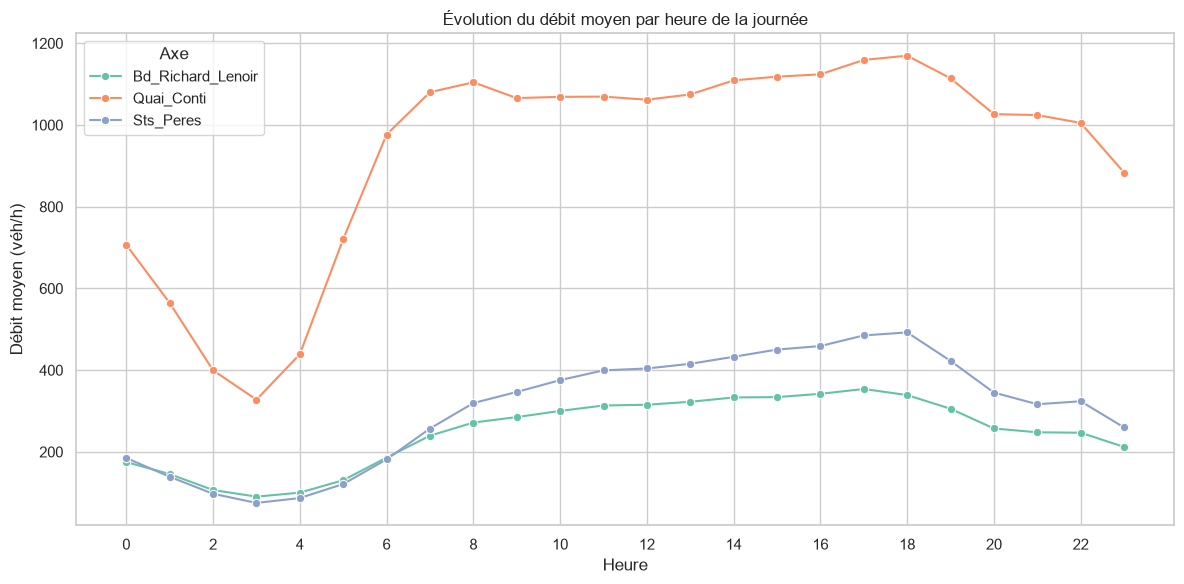

In [10]:
# Extraire l'heure du timestamp
df['heure'] = pd.to_datetime(df['t_1h']).dt.hour

# Calculer le débit moyen par heure et par axe
df_hourly = df.groupby(['libelle', 'heure'])['q'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hourly, x='heure', y='q', hue='libelle', palette="Set2", marker='o')
plt.title("Évolution du débit moyen par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Débit moyen (véh/h)")
plt.xticks(range(0, 24, 2))
plt.legend(title="Axe")
plt.tight_layout()
plt.savefig('graph3_horaire.png', dpi=300)
plt.show()


Ce graphique illustre bien la différence de nature entre nos trois axes. On voit clairement que le Bd Richard Lenoir absorbe un volume de véhicules bien supérieur, avec des pics nets aux heures de pointe (autour de 8h et 19h). À l'inverse, les courbes du Quai Conti et des Saints-Pères sont beaucoup plus basses et plates. 
